importing Jupyter notebook from file_1_data_processing.ipynb
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id             int64  
 1   date           object 
 2   store_nbr      int64  
 3   product_type   object 
 4   sales          float64
 5   special_offer  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']
[ 1 10 11 12 13 14 15 16 17 18 19  2 20 21 22 23 24 25 26 27 28 29  3 30
 31 

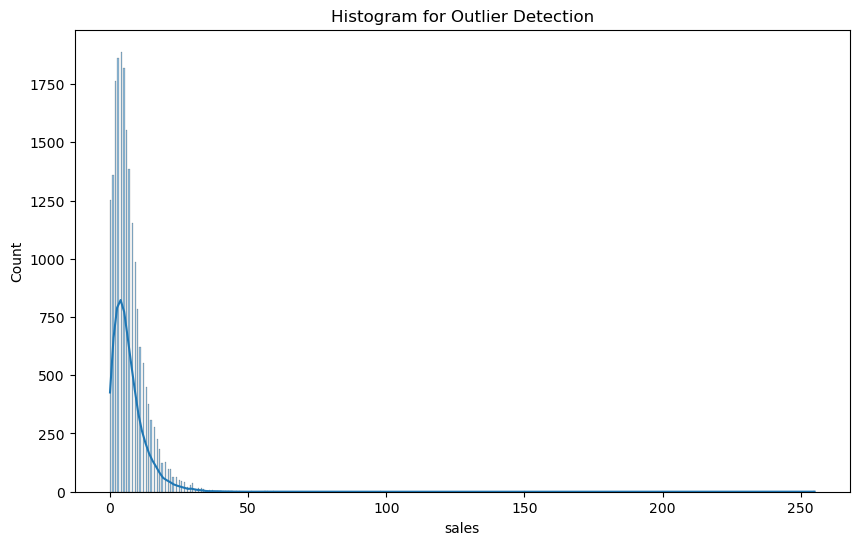

In [2]:
import import_ipynb
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from file_1_data_processing import *

In [41]:
#2.1. Find relationship between sales and special offer
import statsmodels.api as sm
# Add a constant term to the independent variables
X = sm.add_constant(data_train.iloc[:,6:34:2])

# Define dependent variable
y = data_train['sales']

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())
#p-value is low, which means there is significant relationship between sales and special offer

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                 4.148e+05
Date:                Wed, 06 Dec 2023   Prob (F-statistic):               0.00
Time:                        12:24:38   Log-Likelihood:            -4.6394e+06
No. Observations:              625482   AIC:                         9.279e+06
Df Residuals:                  625467   BIC:                         9.279e+06
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.6674      0.542      6.762   

In [3]:
#2.2. Create List of unique products and stores
products = data_train['product_type'].unique()
stores = data_train['store_nbr'].unique()

In [4]:
#2.3. Create lagged features for each product at each store for the train set as data for the last 14 days
for product in products:
    for store in stores:
        # Filter data for the current product and store
        condition = (data_train['product_type'] == product) & (data_train['store_nbr'] == store)
        subset = data_train.loc[condition].copy()
        
        # Skip empty subsets
        if subset.empty:
            continue

        # Set lagged features to be the past 14 values
        num_lags = 14
        for i in range(1, num_lags + 1):
            subset[f'sales_lag_{i}'] = subset['sales'].shift(i)
            subset[f'offer_lag_{i}'] = subset['special_offer'].shift(i)

        # Drop rows with NaN values resulting from lagged shifting
        subset = subset.dropna()

        # Update the original DataFrame with the lagged features
        data_train.loc[condition, subset.columns] = subset

# Drop NaN value resulting from the lagged variable
data_train = data_train.dropna()
data_train

,id,date,store_nbr,product_type,sales,special_offer,sales_lag_1,offer_lag_1,sales_lag_2,offer_lag_2,...,sales_lag_10,offer_lag_10,sales_lag_11,offer_lag_11,sales_lag_12,offer_lag_12,sales_lag_13,offer_lag_13,sales_lag_14,offer_lag_14
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15,1970892.0,2016-01-15,1.0,AUTOMOTIVE,5.000,0.0,2.000,0.0,2.000,0.0,...,7.000,0.0,8.00000,0.0,1.00000,0.0,7.00000,0.0,0.000,0.0
2016-01-15,1970893.0,2016-01-15,1.0,BABY CARE,0.000,0.0,0.000,0.0,0.000,0.0,...,0.000,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.0,0.000,0.0
2016-01-15,1970894.0,2016-01-15,1.0,BEAUTY,2.000,0.0,1.000,0.0,1.000,0.0,...,4.000,0.0,2.00000,0.0,2.00000,0.0,0.00000,0.0,0.000,0.0
2016-01-15,1970895.0,2016-01-15,1.0,BEVERAGES,2100.000,2.0,2422.000,4.0,2141.000,4.0,...,2374.000,9.0,3005.00000,3.0,1048.00000,1.0,1856.00000,7.0,0.000,0.0
2016-01-15,1970896.0,2016-01-15,1.0,BOOKS,0.000,0.0,0.000,0.0,0.000,0.0,...,0.000,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31,2596369.0,2016-12-31,9.0,POULTRY,687.853,1.0,669.283,20.0,411.982,1.0,...,329.632,0.0,372.95502,0.0,659.32404,1.0,458.02402,1.0,414.634,21.0
2016-12-31,2596370.0,2016-12-31,9.0,PREPARED FOODS,100.405,1.0,99.106,2.0,115.901,2.0,...,73.064,2.0,84.32400,2.0,142.46300,2.0,121.47700,1.0,124.490,3.0
2016-12-31,2596371.0,2016-12-31,9.0,PRODUCE,3091.356,3.0,2136.871,3.0,1662.373,5.0,...,2475.507,148.0,1589.41900,3.0,2318.83200,4.0,1542.59700,3.0,1233.849,3.0


In [5]:
#Check the accuracy of lagged features
condition = (data_train['product_type'] == "MEATS") & (data_train['store_nbr'] == 1)
subset = data_train.loc[condition].copy()
df_test = data_train.loc[condition, subset.columns]
df_test

,id,date,store_nbr,product_type,sales,special_offer,sales_lag_1,offer_lag_1,sales_lag_2,offer_lag_2,...,sales_lag_10,offer_lag_10,sales_lag_11,offer_lag_11,sales_lag_12,offer_lag_12,sales_lag_13,offer_lag_13,sales_lag_14,offer_lag_14
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15,1970916.0,2016-01-15,1.0,MEATS,673.71400,46.0,307.523,2.0,306.085,1.0,...,412.12500,0.0,358.59702,0.0,114.82500,0.0,222.96700,0.0,0.00000,0.0
2016-01-16,1972698.0,2016-01-16,1.0,MEATS,230.92400,1.0,673.714,46.0,307.523,2.0,...,309.48300,0.0,412.12500,0.0,358.59702,0.0,114.82500,0.0,222.96700,0.0
2016-01-17,1974480.0,2016-01-17,1.0,MEATS,126.68700,0.0,230.924,1.0,673.714,46.0,...,237.46100,0.0,309.48300,0.0,412.12500,0.0,358.59702,0.0,114.82500,0.0
2016-01-18,1976262.0,2016-01-18,1.0,MEATS,281.43700,0.0,126.687,0.0,230.924,1.0,...,645.50903,46.0,237.46100,0.0,309.48300,0.0,412.12500,0.0,358.59702,0.0
2016-01-19,1978044.0,2016-01-19,1.0,MEATS,256.81702,1.0,281.437,0.0,126.687,0.0,...,231.83300,0.0,645.50903,46.0,237.46100,0.0,309.48300,0.0,412.12500,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,2587488.0,2016-12-27,1.0,MEATS,229.28100,0.0,80.884,0.0,191.958,0.0,...,687.60100,44.0,247.61299,0.0,243.17800,0.0,233.17800,1.0,225.81500,0.0
2016-12-28,2589270.0,2016-12-28,1.0,MEATS,236.94200,2.0,229.281,0.0,80.884,0.0,...,263.45700,0.0,687.60100,44.0,247.61299,0.0,243.17800,0.0,233.17800,1.0
2016-12-29,2591052.0,2016-12-29,1.0,MEATS,234.88200,1.0,236.942,2.0,229.281,0.0,...,176.26000,0.0,263.45700,0.0,687.60100,44.0,247.61299,0.0,243.17800,0.0


In [6]:
#2.4.Scaling lagged features

from sklearn.preprocessing import MinMaxScaler
import pandas as pd

data_train_scaled = data_train.copy()

for product in products:
    # Iterate through each store
    for store in stores:
        # Filter data for the current product and store
        condition = (data_train_scaled['product_type'] == product) & (data_train_scaled['store_nbr'] == store)
        subset = data_train_scaled.loc[condition].copy()

        # Skip empty subsets
        if subset.empty:
            continue

        # Instantiate MinMaxScaler
        scaler = MinMaxScaler()

        # Fit and transform the feature columns (from index 9 to 36)
        data_train_scaled.loc[condition, data_train_scaled.columns[5:34]] = scaler.fit_transform(subset.iloc[:, 5:34])

# Display the scaled DataFrame
data_train_scaled

,id,date,store_nbr,product_type,sales,special_offer,sales_lag_1,offer_lag_1,sales_lag_2,offer_lag_2,...,sales_lag_10,offer_lag_10,sales_lag_11,offer_lag_11,sales_lag_12,offer_lag_12,sales_lag_13,offer_lag_13,sales_lag_14,offer_lag_14
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15,1970892.0,2016-01-15,1.0,AUTOMOTIVE,5.000,0.000000,0.117647,0.000000,0.117647,0.000000,...,0.411765,0.000000,0.470588,0.000000,0.058824,0.000000,0.411765,0.000000,0.000000,0.000000
2016-01-15,1970893.0,2016-01-15,1.0,BABY CARE,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-15,1970894.0,2016-01-15,1.0,BEAUTY,2.000,0.000000,0.111111,0.000000,0.111111,0.000000,...,0.444444,0.000000,0.222222,0.000000,0.222222,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-15,1970895.0,2016-01-15,1.0,BEVERAGES,2100.000,0.023810,0.418363,0.047619,0.356195,0.047619,...,0.407743,0.107143,0.547345,0.035714,0.114381,0.011905,0.293142,0.083333,0.000000,0.000000
2016-01-15,1970896.0,2016-01-15,1.0,BOOKS,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31,2596369.0,2016-12-31,9.0,POULTRY,687.853,0.040000,0.215079,0.800000,0.083041,0.040000,...,0.040782,0.000000,0.063014,0.000000,0.209968,0.040000,0.106668,0.040000,0.188568,0.840000
2016-12-31,2596370.0,2016-12-31,9.0,PREPARED FOODS,100.405,0.076923,0.298963,0.153846,0.399384,0.153846,...,0.143251,0.153846,0.210577,0.153846,0.558205,0.153846,0.432724,0.076923,0.575408,0.230769
2016-12-31,2596371.0,2016-12-31,9.0,PRODUCE,3091.356,0.020270,0.402722,0.020270,0.255347,0.033784,...,0.710274,1.000000,0.325403,0.020690,0.642223,0.027586,0.305066,0.020690,0.392628,0.020690


In [8]:
#2.5. Create rolling mean features for each product at each store

data_train_rmean = data.loc['2016',].copy()
# Define the window size for the rolling statistics
window_size = 14

for product in products:
    for store in stores:
        # Filter data for the current product and store
        condition = (data_train_rmean['product_type'] == product) & (data_train_rmean['store_nbr'] == store)
        subset = data_train_rmean.loc[condition].copy()
        
        # Skip empty subsets
        if subset.empty:
            continue

        # Calculate rolling mean and standard deviation
        subset['sales_mean'] = subset['sales'].rolling(window=window_size).mean()
        subset['sales_std'] = subset['sales'].rolling(window=window_size).std()
        subset['offer_mean'] = subset['special_offer'].rolling(window=window_size).mean()
        subset['offer_std'] = subset['special_offer'].rolling(window=window_size).std()

        # Drop rows with NaN values 
        subset = subset.dropna()

        # Update the original DataFrame
        data_train_rmean.loc[condition, subset.columns] = subset

# Now, 'data_train' contains rolling mean for each product at each store
data_train_rmean = data_train_rmean.dropna()
data_train_rmean

,id,date,store_nbr,product_type,sales,special_offer,sales_mean,sales_std,offer_mean,offer_std
date,,,,,,,,,,
2016-01-14,1969110.0,2016-01-14,1.0,AUTOMOTIVE,2.000,0.0,4.357143,2.871803,0.000000,0.000000
2016-01-14,1969111.0,2016-01-14,1.0,BABY CARE,0.000,0.0,0.000000,0.000000,0.000000,0.000000
2016-01-14,1969112.0,2016-01-14,1.0,BEAUTY,1.000,0.0,1.428571,1.452546,0.000000,0.000000
2016-01-14,1969113.0,2016-01-14,1.0,BEVERAGES,2422.000,4.0,1985.142857,797.958343,3.071429,2.758603
2016-01-14,1969114.0,2016-01-14,1.0,BOOKS,0.000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2016-12-31,2596369.0,2016-12-31,9.0,POULTRY,687.853,1.0,548.441219,144.592883,3.214286,7.127181
2016-12-31,2596370.0,2016-12-31,9.0,PREPARED FOODS,100.405,1.0,105.656785,22.589668,3.000000,2.882307
2016-12-31,2596371.0,2016-12-31,9.0,PRODUCE,3091.356,3.0,2205.345286,693.682306,23.642857,51.224404


In [9]:
# 2.6. Choose only 14 features with the RFE model
features = data_train.copy().drop(["id","date","store_nbr","product_type","sales","special_offer"], axis = 1) #Extract the features
features

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
# separate into input and output variables
X = features
y = data_train['sales']
# Define the number of features
n_features_to_select = 14 

# Create a linear regression model
model = LinearRegression()

# Create a time series split for cross-validation
tscv = TimeSeriesSplit(n_splits=5) 

# Create RFE model
rfe = RFE(estimator=model, n_features_to_select=n_features_to_select)

# Fit RFE
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rfe = rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]


In [10]:
#Extract the refined 14 features
refined_features = data_train[list(selected_features)]
refined_features

,offer_lag_1,offer_lag_3,offer_lag_5,offer_lag_6,sales_lag_7,offer_lag_7,offer_lag_8,offer_lag_9,offer_lag_10,offer_lag_11,offer_lag_12,offer_lag_13,sales_lag_14,offer_lag_14
date,,,,,,,,,,,,,,
2016-01-15,0.0,0.0,0.0,0.0,5.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2016-01-15,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2016-01-15,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2016-01-15,4.0,4.0,4.0,0.0,2208.00000,1.0,0.0,5.0,9.0,3.0,1.0,7.0,0.000,0.0
2016-01-15,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31,20.0,1.0,0.0,0.0,727.81903,20.0,0.0,0.0,0.0,0.0,1.0,1.0,414.634,21.0
2016-12-31,2.0,8.0,2.0,2.0,100.45400,3.0,1.0,11.0,2.0,2.0,2.0,1.0,124.490,3.0
2016-12-31,3.0,4.0,3.0,3.0,2575.08300,3.0,4.0,4.0,148.0,3.0,4.0,3.0,1233.849,3.0


In [11]:
#Add the refined features to training set
data_train_refined = data_train.drop(data_train.iloc[:,6:34],axis = 1)
data_train_refined = pd.concat([data_train_refined, refined_features], axis=1)
data_train_refined

,id,date,store_nbr,product_type,sales,special_offer,offer_lag_1,offer_lag_3,offer_lag_5,offer_lag_6,sales_lag_7,offer_lag_7,offer_lag_8,offer_lag_9,offer_lag_10,offer_lag_11,offer_lag_12,offer_lag_13,sales_lag_14,offer_lag_14
date,,,,,,,,,,,,,,,,,,,,
2016-01-15,1970892.0,2016-01-15,1.0,AUTOMOTIVE,5.000,0.0,0.0,0.0,0.0,0.0,5.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2016-01-15,1970893.0,2016-01-15,1.0,BABY CARE,0.000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2016-01-15,1970894.0,2016-01-15,1.0,BEAUTY,2.000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2016-01-15,1970895.0,2016-01-15,1.0,BEVERAGES,2100.000,2.0,4.0,4.0,4.0,0.0,2208.00000,1.0,0.0,5.0,9.0,3.0,1.0,7.0,0.000,0.0
2016-01-15,1970896.0,2016-01-15,1.0,BOOKS,0.000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31,2596369.0,2016-12-31,9.0,POULTRY,687.853,1.0,20.0,1.0,0.0,0.0,727.81903,20.0,0.0,0.0,0.0,0.0,1.0,1.0,414.634,21.0
2016-12-31,2596370.0,2016-12-31,9.0,PREPARED FOODS,100.405,1.0,2.0,8.0,2.0,2.0,100.45400,3.0,1.0,11.0,2.0,2.0,2.0,1.0,124.490,3.0
2016-12-31,2596371.0,2016-12-31,9.0,PRODUCE,3091.356,3.0,3.0,4.0,3.0,3.0,2575.08300,3.0,4.0,4.0,148.0,3.0,4.0,3.0,1233.849,3.0


In [12]:
#2.7. Add time-based variables
data_train_timebased = data.loc['2016',].copy()
data_train_timebased['Month'] = data_train_timebased.index.month
data_train_timebased['Day'] = data_train_timebased.index.day
data_train_timebased['Year'] = data_train_timebased.index.year
data_train_timebased

,id,date,store_nbr,product_type,sales,special_offer,Month,Day,Year
date,,,,,,,,,
2016-01-01,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0,1,1,2016
2016-01-01,1945945,2016-01-01,1,BABY CARE,0.000,0,1,1,2016
2016-01-01,1945946,2016-01-01,1,BEAUTY,0.000,0,1,1,2016
2016-01-01,1945947,2016-01-01,1,BEVERAGES,0.000,0,1,1,2016
2016-01-01,1945948,2016-01-01,1,BOOKS,0.000,0,1,1,2016
...,...,...,...,...,...,...,...,...,...
2016-12-31,2596369,2016-12-31,9,POULTRY,687.853,1,12,31,2016
2016-12-31,2596370,2016-12-31,9,PREPARED FOODS,100.405,1,12,31,2016
2016-12-31,2596371,2016-12-31,9,PRODUCE,3091.356,3,12,31,2016


In [30]:
#Hyperparameter tuning for Random forest
import scipy.stats as sp
param_dist = dict(n_estimators = sp.randint(5,20,1), max_depth = [10,20,30,40,50])
from sklearn.model_selection import RandomizedSearchCV
n_iter_search = 10
randsearch = RandomizedSearchCV(RandomForestRegressor(), param_distributions = param_dist, n_iter = n_iter_search, cv = 10, n_jobs = 2)
randsearch.fit(data_train.iloc[:,6:34:2], data_train['sales'])
print('Best param sets:', randsearch.best_params_)
print('Mean score:', randsearch.best_score_)

Best param sets: {'max_depth': 20, 'n_estimators': 19}
Mean score: 0.918601823738842


# Cross-validation for ML models

0. Baseline model

In [33]:
#MSE of baseline model to compare with
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

# Assign 'y_true' as the actual target variable and 'y_pred_mean' as the mean prediction
y_true = data_train['sales'] 
y_pred_mean = np.full_like(y_true, y_true.mean())  # Predicting the mean for every sample

#Calculate 
mae_base = mean_absolute_error(y_true,y_pred_mean) 
print(f'Mean Absolute Error for Mean Prediction: {mae_base}')

# Calculate MSE for the mean prediction
mse_base = mean_squared_error(y_true, y_pred_mean)
print(f'Mean Squared Error for Mean Prediction: {mse_base}')

r2_base = r2_score(y_true, y_pred_mean)
print(f'R-squared for Mean Prediction: {r2_base}')

Mean Absolute Error for Mean Prediction: 621.3057110869208
Mean Squared Error for Mean Prediction: 1668600.0989209986
R-squared for Mean Prediction: 0.0


1. Lagged sales and offer for previous 14 days

In [14]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#Linear Regression with lagged features with raw data

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = data_train.iloc[:,5:34]
y = data_train['sales']
        
# Perform time series cross-validation and get MSE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mae_linear = -np.mean(mae_scores)
# Display the mean of mean squared error scores
print(f'MAE Scores for Linear Regression with raw data: {mean_mae_linear}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_linear = -np.mean(mse_scores)
# Display the mean of mean squared error scores
print(f'MSE Scores for Linear Regression with raw data: {mean_mse_linear}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_linear = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with raw data: {mean_r2_linear}')

MAE Scores for Linear Regression with raw data: 79.40620801283244
MSE Scores for Linear Regression with raw data: 217213.93773326586
R2 Scores for Linear Regression with raw data: 0.8842980392350075


In [35]:
#Random Forest with raw data 

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = RandomForestRegressor(n_estimators=10, random_state=42)

X = data_train.iloc[:, 5:34]
y = data_train['sales']

# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mean_mae_RF = -np.mean(mae_scores)
# Display the mean of MSE scores
print(f'MAE Scores for RF with raw data: {mean_mae_RF}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_RF = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with raw data: {mean_mse_RF}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_RF = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'Mean of R2 Scores for RF: {mean_r2_RF}')

MAE Scores for RF with raw data: 76.19031385645904
MSE Scores for RF with raw data: 288669.2404351422
Mean of R2 Scores for RF: 0.8291723882156491


1.1. Lagged features with scaling 

In [15]:
#Linear Regression with scaled data

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = data_train_scaled.iloc[:,5:34]
y = data_train_scaled['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Display the mean of mean squared error scores
mae_linear_scaled = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression with scaled data: {mae_linear_scaled}')
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Display the mean of mean squared error scores
mse_linear_scaled = -np.mean(mse_scores)
print(f'MSE Scores for Linear Regression with scaled data: {mse_linear_scaled}')
# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_linear_scaled = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with scaled data: {r2_linear_scaled}')

MAE Scores for Linear Regression with scaled data: 595.547885985093
MSE Scores for Linear Regression with scaled data: 1519971.899732209
R2 Scores for Linear Regression with scaled data: 0.10036435403991895


In [16]:
#Random Forest with scaled data

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)
# Initialize linear regression model
model = RandomForestRegressor(n_estimators=10, random_state=42)

X = data_train_scaled.iloc[:,5:34]
y = data_train_scaled['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_RF_scaled = -np.mean(mae_scores)
# Display the mean of MAE scores
print(f'MAE Scores for RF with scaled data: {mae_RF_scaled}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_RF_scaled = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with scaled data: {mse_RF_scaled}')

# Perform time series cross-validation and get R2 scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R2 score
r2_RF_scaled = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for RF with scaled data: {r2_RF_scaled}')

MAE Scores for RF with scaled data: 427.35009828609316
MSE Scores for RF with scaled data: 1327929.2391246527
R2 Scores for RF with scaled data: 0.2247341985568681


2. Lagged sales for previous 14 days only

In [17]:
#Linear Regression with only lagged sales

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)
# Initialize linear regression model
model = LinearRegression()

X = data_train.iloc[:,6:34:2]
y = data_train['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_linear_sales = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression with only lagged sales: {mae_linear_sales}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_linear_sales = -np.mean(mse_scores)
print(f'MSE Scores for Linear Regression with only lagged sales: {mse_linear_sales}')

# Perform time series cross-validation and get R2 scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean MSE score
r2_linear_sales = np.mean(r2_scores)
print(f'R2 Scores for Linear Regression with only lagged sales: {r2_linear_sales}')

MAE Scores for Linear Regression with only lagged sales: 78.0317981608363
MSE Scores for Linear Regression with only lagged sales: 221574.03155513387
R2 Scores for Linear Regression with only lagged sales: 0.8821067630722581


In [26]:
#Random Forest with lagged sales
# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = RandomForestRegressor(n_estimators=10, random_state=42)

X = data_train.iloc[:, 6:34:2]
y = data_train['sales']

# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_RF_sales = -np.mean(mae_scores)
# Display the mean of MAE scores
print(f'MAE Scores for RF with only lagged sales: {mae_RF_sales}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_RF_sales = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with only lagged sales: {mse_RF_sales}')

# Perform time series cross-validation and get R2 scores for each split
mse_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_RF_sales = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for RF with only lagged sales: {r2_RF_sales}')

MAE Scores for RF with only lagged sales: 72.87512864040264
MSE Scores for RF with only lagged sales: 190254.11612387118
R2 Scores for RF with only lagged sales: -0.007359067854497914


In [34]:
#Random Forest with lagged sales with 20 estimators
# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = RandomForestRegressor(n_estimators=20, random_state=42)

X = data_train.iloc[:, 6:34:2]
y = data_train['sales']

# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_RF_sales = -np.mean(mae_scores)
# Display the mean of MAE scores
print(f'MAE Scores for RF with only lagged sales with 20 estimators: {mae_RF_sales}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_RF_sales = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with only lagged sales with 20 estimators: {mse_RF_sales}')

# Perform time series cross-validation and get R2 scores for each split
mse_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_RF_sales = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for RF with only lagged sales with 20 estimators: {r2_RF_sales}')

MAE Scores for RF with only lagged sales with 20 estimators: 71.05913951192133
MSE Scores for RF with only lagged sales with 20 estimators: 186547.2421745376
R2 Scores for RF with only lagged sales with 20 estimators: -0.007359067854497914


3. Refined lagged features

In [19]:
#Linear Regression with refined lagged features

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize linear regression model
model = LinearRegression()

X = data_train_refined.iloc[:,6:20]
y = data_train_refined['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_linear_refined = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression with refined features: {mae_linear_refined}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_linear_refined = -np.mean(mse_scores)
print(f'MSE Scores for Linear Regression with refined features: {mse_linear_refined}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_linear_refined = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression refined features: {r2_linear_refined}')

MAE Scores for Linear Regression with refined features: 91.47695789151615
MSE Scores for Linear Regression with refined features: 247644.60916398466
R2 Scores for Linear Regression refined features: 0.8652797605876232


In [20]:
#Random Forest with refined lagged features

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize Random Forest Regressor model
model = RandomForestRegressor(n_estimators=10, random_state=42)

X = data_train_refined.iloc[:,6:20]
y = data_train_refined['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_RF_refined = -np.mean(mae_scores)
print(f'MAE Scores for Random Forest with refined features: {mae_RF_refined}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_RF_refined = -np.mean(mse_scores)
print(f'MSE Scores for Random Forest with refined features: {mse_RF_refined}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_RF_refined = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Random Forest with refined features: {r2_RF_refined}')

MAE Scores for Random Forest with refined features: 92.94412038964785
MSE Scores for Random Forest with refined features: 359493.97574500943
R2 Scores for Random Forest with refined features: 0.7832742605006124


4. Rolling means for the last 14 days

In [21]:
#Linear Regression with rolling means with raw data

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = data_train_rmean.iloc[:,6:10]
y = data_train_rmean['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Display the mean of MAE scores
mae_linear_rmean = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression with rolling means: {mae_linear_rmean}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Display the mean of mean squared error scores
mse_linear_rmean = -np.mean(mse_scores)
print(f'MSE Scores for Linear Regression with rolling means: {mse_linear_rmean}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_linear_rmean = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with rolling means: {r2_linear_rmean}')

MAE Scores for Linear Regression with rolling means: 106.03600198094031
MSE Scores for Linear Regression with rolling means: 227480.0213261046
R2 Scores for Linear Regression with rolling means: 0.8740703635556087


In [22]:
#Random Forest with rolling means with raw data

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = RandomForestRegressor(n_estimators=10, random_state=42)

X = data_train_rmean.iloc[:,6:10]
y = data_train_rmean['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Display the mean of MAE scores
mae_RF_rmean = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression with rolling means: {mae_RF_rmean}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Display the mean of mean squared error scores
mse_RF_rmean = -np.mean(mse_scores)
print(f'MSE Scores for Linear Regression with rolling means: {mse_RF_rmean}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_RF_rmean = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with rolling means: {r2_RF_rmean}')

MAE Scores for Linear Regression with rolling means: 117.67948124355162
MSE Scores for Linear Regression with rolling means: 266411.5256532246
R2 Scores for Linear Regression with rolling means: 0.851644952320553


5. Time-based features

In [23]:
#Linear Regression with raw data with time-based features
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)
# Initialize linear regression model
model = LinearRegression()

X = data_train_timebased.iloc[:,6:9]
y = data_train_timebased['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_linear_time = -np.mean(mae_scores)
# Display the mean of MAE scores
print(f'MAE Scores for Linear Regression with time-based features: {mae_linear_time}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_linear_time = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for Linear Regression with time-based features: {mse_linear_time}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_linear_time = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with time-based features: {r2_linear_time}')

MAE Scores for Linear Regression with time-based features: 619.5714118738476
MSE Scores for Linear Regression with time-based features: 1707536.6621798933
R2 Scores for Linear Regression with time-based features: -0.0011909239967526019


In [24]:
#Random Forest with raw data with time-based features
# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = RandomForestRegressor(n_estimators=10, random_state=42)

X = data_train_timebased.iloc[:,6:9]
y = data_train_timebased['sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mae_RF_rmean = -np.mean(mae_scores)
# Display the mean of MAE scores
print(f'MAE Scores for Linear Regression with time-based features: {mae_RF_rmean}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mse_RF_rmean = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for Linear Regression with time-based features: {mse_RF_rmean}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
r2_RF_rmean = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with time-based features: {r2_RF_rmean}')

MAE Scores for Linear Regression with time-based features: 617.5936402926939
MSE Scores for Linear Regression with time-based features: 1717922.043288473
R2 Scores for Linear Regression with time-based features: -0.007359067854497914
